## 1. Configuration and Import

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_FOLDER = './data'
TRAIN_PATH = Path(f'{DATA_FOLDER}/train.csv')
TEST_PATH = Path(f'{DATA_FOLDER}/test.csv')

## 2. Helper Functions

In [3]:
def draw_histogram_survivors_per_col(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 3))
    plt.title(f'Survival Counts per {col.capitalize()}')
    sns.histplot(
        data=df,
        x=col,
        hue='Survived',
        multiple='dodge',
        shrink=0.8,
        palette=['#B45447', '#A8C8A6']
    )

In [4]:
def draw_histogram_survivors_per_col_proportion(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 3))
    plt.title(f'Survival Proportions per {col.capitalize()}')
    stats=df.groupby(col, as_index=False)['Survived'].value_counts(normalize=True)
    ax = sns.barplot(
        data=stats,
        x=col,
        y='proportion',
        hue='Survived',
        palette=['#B45447', '#A8C8A6'],
        hue_order=[0, 1],
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge')

In [29]:
def bin_values_with_quantiles(df : pd.DataFrame, col : str, nbins : int):
    quantiles = np.linspace(0, 1, nbins + 1)
    bins = df[col].quantile(quantiles).unique()
    
    return pd.cut(df[col], 
                  bins=bins, 
                  include_lowest=True, 
                  duplicates='drop', 
                  labels=[n + 1 for n in range(nbins)])

In [36]:
def bin_values_custom_bins (df : pd.DataFrame, col : str, bins : list):
    return pd.cut(df[col], 
                  bins=bins, 
                  include_lowest=True, 
                  duplicates='drop', 
                  labels=[n + 1 for n in range(len(bins) - 1)])

## 3. Read Data

### 3.1 Load Data ###

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

In [7]:
display(train_df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3.2 Data Overview

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Conclusions:**
* There are missing data in Age (around 20%), Cabin (around 77%) and Embarked (around 0.2%) columns
* The lowest age is 0.42 - dataset is relatively small, consider bins
* The lowest Fare is 0 -> might be also a missing value

## 4. EDA

In [10]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### 4.1 Histograms ###

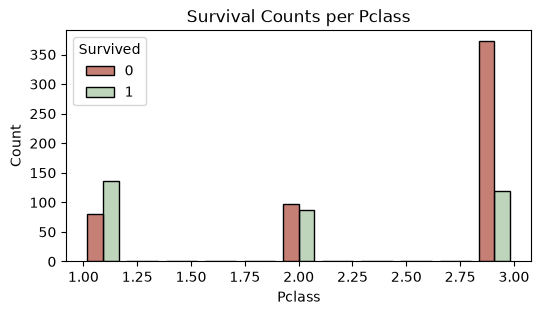

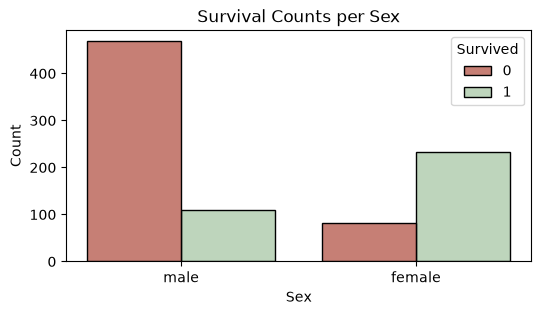

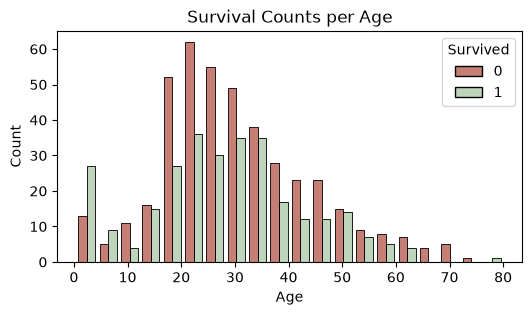

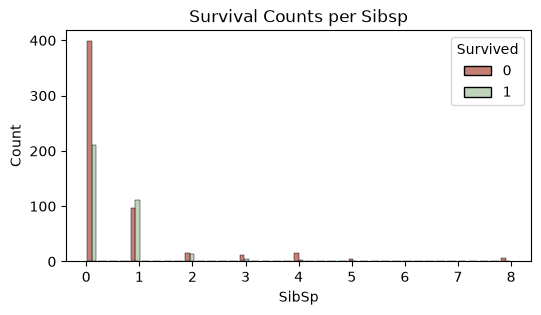

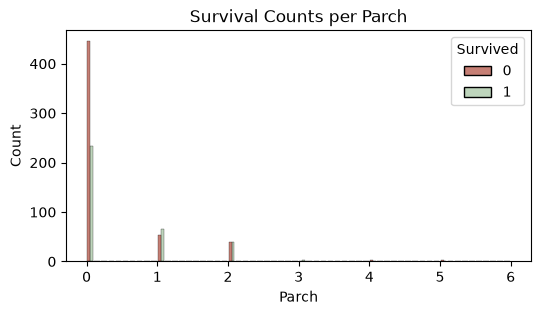

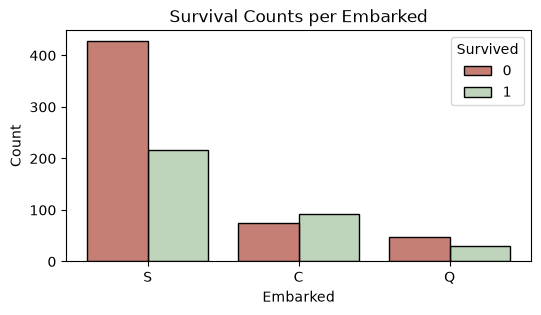

In [11]:
cols_to_investigate=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']
for col in cols_to_investigate:
    draw_histogram_survivors_per_col(train_df, col)

### 4.2 % of Survivors

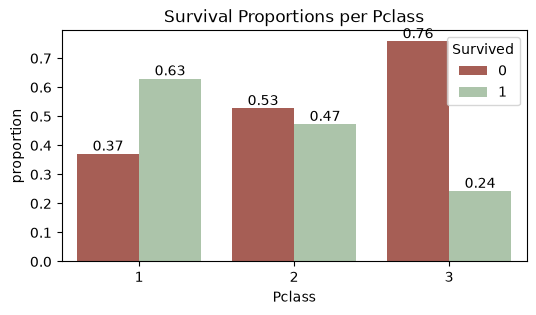

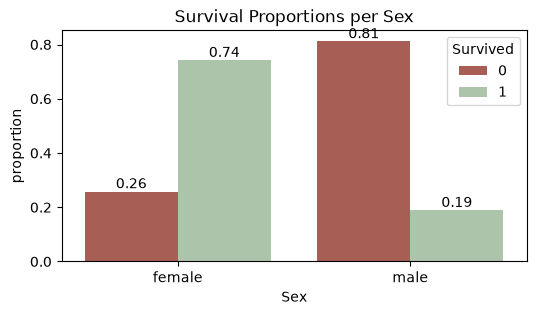

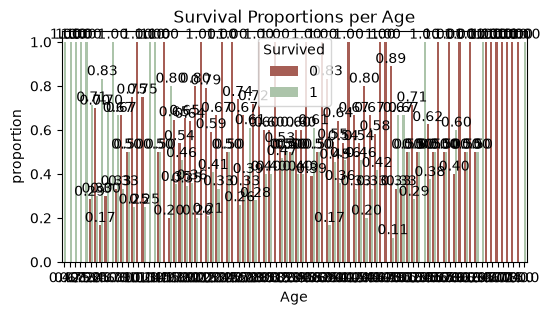

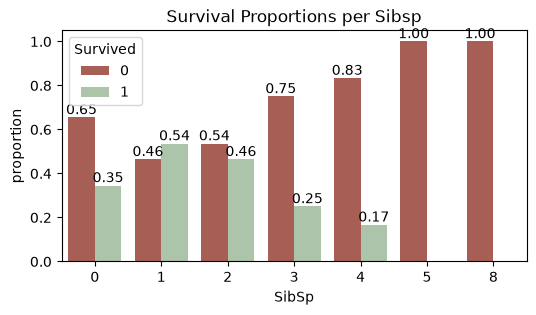

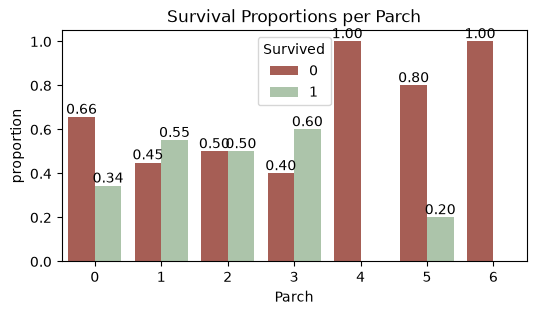

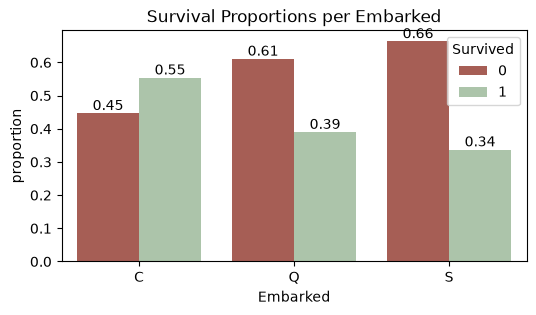

In [12]:
for col in cols_to_investigate:
    draw_histogram_survivors_per_col_proportion(train_df, col)

### 4.3 Conclusions
* There is stron correclation between surviving and Embarked, SibSp, Sex and PClass
* Data per Age is too granular, this feature needs to be aggregated into bins

## 5. Feature Engineering

### 5.1 Handling missing values
Due to the dataset size, removing columns or rows is not a preffarable method
* **Age** - Fill using median per Sex, Pclass and title extracted from name, 
* **Cabin** - Change to IsCabin variable, which indicates whether cabin is known. Based on the data, cabin is knows for richer passenger, so there might be a correlation between this information and survivng (will be done in *5.5 Create new features* section)
* **Embarked** - Analyze the missing cases. Fill based on the Fare

In [ ]:
#Age
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

median_age = train_df.groupby(['Pclass', 'Sex', 'Title'])['Age'].transform('median')



<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\domin\AppData\Local\Temp\ipykernel_14960\3048407358.py:2: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


0      26.0
1      41.5
2      18.0
3      41.5
4      26.0
       ... 
886    46.5
887    30.0
888    18.0
889    40.0
890    26.0
Name: Age, Length: 891, dtype: float64

In [44]:
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 5.2 Remove unndecessery columns

In [33]:
cleaned_train_df = train_df.drop(
    columns=['PassengerId', 'Name', 'Ticket']
    ,axis=1
)

### 5.3 Bin Age and Fare

In [34]:
cleaned_train_df[['Age', 'Fare']].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [37]:
#bins chosen based on real-life age groups
cleaned_train_df['Age_Bin'] = bin_values_custom_bins(cleaned_train_df, 'Age', 
                                                     bins=[0, 12, 18, 35, 60, 100])

#bins chosen based on fare distributions
cleaned_train_df['Fare_Bin']= bin_values_with_quantiles(cleaned_train_df, 'Fare', 10)

cleaned_train_df['Age_Bin'].value_counts()

Age_Bin
3    358
4    195
2     70
1     69
5     22
Name: count, dtype: int64

### 5.4 Encode categorical variables

In [15]:
#Encode Sex variable
cleaned_train_df = pd.get_dummies(cleaned_train_df, columns=['Sex', 'Embarked'])
display(cleaned_train_df.head())

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,2,1,0,0,NaN,False,True,False,False,True
1,1,1,3,1,0,3,C85,True,False,True,False,False
2,1,3,2,0,0,1,NaN,True,False,False,False,True
3,1,1,2,1,0,3,C123,True,False,False,False,True
4,0,3,2,0,0,1,NaN,False,True,False,False,True


### 5.5 Create new features

In [16]:
cleaned_train_df['Cabin_isnull'] = cleaned_train_df['Cabin'].isnull().astype(int)
cleaned_train_df['Family_Size'] = cleaned_train_df['SibSp'] + cleaned_train_df['Parch']
cleaned_train_df['IsAlone'] = (cleaned_train_df['Family_Size'] == 0).astype(int)

cleaned_train_df = cleaned_train_df.drop(columns=['Cabin', 'SibSp', 'Parch'], axis=1)

In [17]:
cleaned_train_df.head()

,Survived,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_isnull,Family_Size,IsAlone
0,0,3,2,0,False,True,False,False,True,1,1,0
1,1,1,3,3,True,False,True,False,False,0,1,0
2,1,3,2,1,True,False,False,False,True,1,0,1
3,1,1,2,3,True,False,False,False,True,0,1,0
4,0,3,2,1,False,True,False,False,True,1,0,1


## 6. Model

To do:
* handling missing values
* creating bins as a function - test different variations
* create a pipeline for feature engineering